
<h1 style = "color:orange;" dir = "ltr"> <b>
    NNDL-HW6
</b> </h1>

<h1 style = "color:white;" dir = "ltr"> <b>
        Negar Shamaie-810101450
</b> </h1>


<a id='st1'></a>
<h1 style = "color:white;" dir = "ltr"> <b>
        Loading and Main Functions
        
</b> </h1>

In [ ]:
import os
import gzip
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
from torchvision.models import inception_v3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
epochs = 99
lr = 0.0002
latent_dim = 32
image_size = 28
channels = 1
DATA_DIR = "/kaggle/input/datasets/hojjatk/mnist-dataset" 

def load_local_mnist_images(filename):
    filepath = os.path.join(DATA_DIR, filename)
    with open(filepath, 'rb') as f:
        magic, num, rows, cols = np.frombuffer(f.read(16), dtype=np.uint32, count=4).byteswap()
        raw_data = np.frombuffer(f.read(), dtype=np.uint8)
        images = raw_data.reshape(num, 1, rows, cols).astype(np.float32)
        images = (images / 125.5) - 1.0 
        return torch.tensor(images)

def load_local_mnist_labels(filename):
    filepath = os.path.join(DATA_DIR, filename)
    with open(filepath, 'rb') as f:
        magic, num = np.frombuffer(f.read(8), dtype=np.uint32, count=2).byteswap()
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return torch.tensor(labels, dtype=torch.long)

print("Loading IDX datasets from local directory...")
x_train = load_local_mnist_images("train-images.idx3-ubyte")
y_train = load_local_mnist_labels("train-labels.idx1-ubyte")
train_dataset = TensorDataset(x_train, y_train)
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
print(f"Dataset completely loaded. Total training batches: {len(dataloader)}")

inception_model = inception_v3(pretrained=True, transform_input=False).to(device)
inception_model.eval()
if hasattr(inception_model, 'fc'):
    inception_model.fc = nn.Identity()

def calculate_fid(real_features, fake_features):
    mu_real, sigma_real = np.mean(real_features, axis=0), np.cov(real_features, rowvar=False)
    mu_fake, sigma_fake = np.mean(fake_features, axis=0), np.cov(fake_features, rowvar=False)
    diff = mu_real - mu_fake
    covmean, _ = sqrtm(sigma_real.dot(sigma_fake), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return diff.dot(diff) + np.trace(sigma_real + sigma_fake - 2.0 * covmean)

def get_inception_features(images):

    upsampled = F.interpolate(
        images,
        size=(299,299),
        mode='bilinear',
        align_corners=False
    )
    if upsampled.shape[1] == 1:
        upsampled = upsampled.repeat(1,3,1,1)
    upsampled = (upsampled + 1.0) / 2.0
    mean = torch.tensor(
        [0.485,0.456,0.406],
        device=upsampled.device
    ).view(1,3,1,1)
    std = torch.tensor(
        [0.229,0.224,0.225],
        device=upsampled.device
    ).view(1,3,1,1)
    upsampled = (upsampled - mean) / std
    with torch.no_grad():
        features = inception_model(upsampled)
    return features.cpu().numpy()

def plot_training_loss(loss_dict, title):
    plt.figure(figsize=(10, 4))
    for label, losses in loss_dict.items():
        plt.plot(losses, label=label)
    plt.title(title)
    plt.xlabel("Iterations")
    plt.ylabel("Loss Scale")
    plt.legend()
    plt.grid(True)
    plt.show()

def show_generated_samples(generator, latent_dimension, title, num_samples=16, is_began=False):
    generator.eval()
    with torch.no_grad():
        if is_began:
            noise = torch.randn(num_samples, 32, device=device)
        else:
            noise = torch.randn(num_samples, latent_dimension, 1, 1, device=device)
        fake_images = generator(noise).detach().cpu()
    grid = vutils.make_grid(fake_images, nrow=4, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(5, 5))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.title(title)
    plt.axis("off")
    plt.show()

Loading IDX datasets from local directory...
Dataset completely loaded. Total training batches: 937


<a id='st1'></a>
<h1 style = "color:white;" dir = "ltr"> <b>
        Naive GAN
        
</b> </h1>

Running Naïve-GAN optimization cycles...
Epoch [1/99] | Avg Loss D: 0.6462 | Avg Loss G: 3.0152
Epoch [2/99] | Avg Loss D: 0.7280 | Avg Loss G: 1.8758
Epoch [3/99] | Avg Loss D: 0.6705 | Avg Loss G: 2.0715
Epoch [4/99] | Avg Loss D: 0.6458 | Avg Loss G: 2.1668
Epoch [5/99] | Avg Loss D: 0.6230 | Avg Loss G: 2.2711
Epoch [6/99] | Avg Loss D: 0.5838 | Avg Loss G: 2.3808
Epoch [7/99] | Avg Loss D: 0.5749 | Avg Loss G: 2.4548
Epoch [8/99] | Avg Loss D: 0.5255 | Avg Loss G: 2.5689
Epoch [9/99] | Avg Loss D: 0.5212 | Avg Loss G: 2.6298
Epoch [10/99] | Avg Loss D: 0.5016 | Avg Loss G: 2.7157
Epoch [11/99] | Avg Loss D: 0.4704 | Avg Loss G: 2.8017
Epoch [12/99] | Avg Loss D: 0.4511 | Avg Loss G: 2.8958
Epoch [13/99] | Avg Loss D: 0.4362 | Avg Loss G: 2.9707
Epoch [14/99] | Avg Loss D: 0.4444 | Avg Loss G: 2.9901
Epoch [15/99] | Avg Loss D: 0.4087 | Avg Loss G: 3.0845
Epoch [16/99] | Avg Loss D: 0.4236 | Avg Loss G: 3.0697
Epoch [17/99] | Avg Loss D: 0.4176 | Avg Loss G: 3.1283
Epoch [18/99] | 

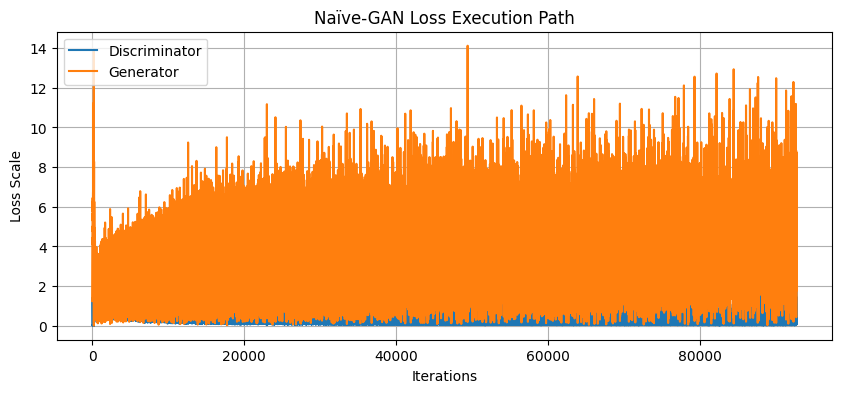

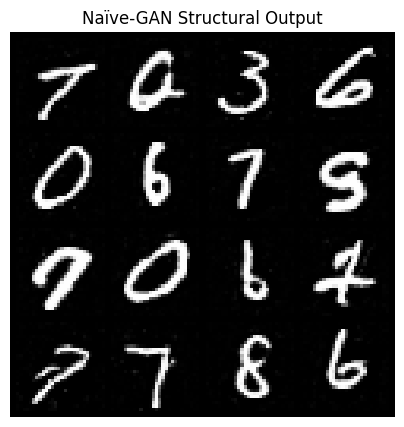

/tmp/ipykernel_58/1689098877.py:54: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma_real.dot(sigma_fake), disp=False)


>> Evaluated FID score for Naïve-GAN: 27.5330



In [18]:
class NaiveGenerator(nn.Module):
    def __init__(self):
        super(NaiveGenerator, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 3, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x):
        return self.model(x)

class NaiveDiscriminator(nn.Module):
    def __init__(self):
        super(NaiveDiscriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(channels, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 3, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x).view(-1, 1)

netG_naive = NaiveGenerator().to(device)
netD_naive = NaiveDiscriminator().to(device)
criterion_bce = nn.BCELoss()
optG_naive = optim.Adam(netG_naive.parameters(), lr=lr, betas=(0.5, 0.999))
optD_naive = optim.Adam(netD_naive.parameters(), lr=lr, betas=(0.5, 0.999))
naive_losses = {"Discriminator": [], "Generator": []}
real_features_naive, fake_features_naive = [], []
print("Running Naïve-GAN optimization cycles...")
for epoch in range(epochs):
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0
    
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        netD_naive.zero_grad()
        labels_real = torch.ones(batch_size, 1, device=device)
        labels_fake = torch.zeros(batch_size, 1, device=device)
        out_real = netD_naive(real_imgs)
        loss_D_real = criterion_bce(out_real, labels_real)
        noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        fake_imgs = netG_naive(noise)
        out_fake = netD_naive(fake_imgs.detach())
        loss_D_fake = criterion_bce(out_fake, labels_fake)
        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optD_naive.step()
        netG_naive.zero_grad()
        out_g = netD_naive(fake_imgs)
        loss_G = criterion_bce(out_g, labels_real)
        loss_G.backward()
        optG_naive.step()

        naive_losses["Discriminator"].append(loss_D.item())
        naive_losses["Generator"].append(loss_G.item())
        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()
        
        if epoch == epochs - 1 and i < 25:
            real_features_naive.append(get_inception_features(real_imgs))
            fake_features_naive.append(get_inception_features(fake_imgs))

    avg_loss_D = epoch_loss_D / len(dataloader)
    avg_loss_G = epoch_loss_G / len(dataloader)
    print(f"Epoch [{epoch+1}/{epochs}] | Avg Loss D: {avg_loss_D:.4f} | Avg Loss G: {avg_loss_G:.4f}")

plot_training_loss(naive_losses, "Naïve-GAN Loss Execution Path")
show_generated_samples(netG_naive, latent_dim, "Naïve-GAN Structural Output")
real_feats = np.concatenate(real_features_naive, axis=0)
fake_feats = np.concatenate(fake_features_naive, axis=0)
print(f">> Evaluated FID score for Naïve-GAN: {calculate_fid(real_feats, fake_feats):.4f}\n")

<a id='st1'></a>
<h1 style = "color:white;" dir = "ltr"> <b>
        WGAN-GP
        
</b> </h1>

Running WGAN-GP optimization cycles...
Epoch [1/99] | Avg Loss Critic: -12.9277 | Avg Loss Generator: 13.1394
Epoch [2/99] | Avg Loss Critic: -10.8969 | Avg Loss Generator: 20.3846
Epoch [3/99] | Avg Loss Critic: -10.8224 | Avg Loss Generator: 18.3226
Epoch [4/99] | Avg Loss Critic: -8.3828 | Avg Loss Generator: 8.0756
Epoch [5/99] | Avg Loss Critic: -8.0230 | Avg Loss Generator: -3.4747
Epoch [6/99] | Avg Loss Critic: -2.7723 | Avg Loss Generator: -7.2750
Epoch [7/99] | Avg Loss Critic: -1.3189 | Avg Loss Generator: 6.0258
Epoch [8/99] | Avg Loss Critic: -1.4232 | Avg Loss Generator: 9.6301
Epoch [9/99] | Avg Loss Critic: -1.3924 | Avg Loss Generator: 10.9327
Epoch [10/99] | Avg Loss Critic: -1.3413 | Avg Loss Generator: 11.2469
Epoch [11/99] | Avg Loss Critic: -1.2746 | Avg Loss Generator: 11.7578
Epoch [12/99] | Avg Loss Critic: -1.2111 | Avg Loss Generator: 12.1967
Epoch [13/99] | Avg Loss Critic: -1.1665 | Avg Loss Generator: 12.4748
Epoch [14/99] | Avg Loss Critic: -1.1406 | Avg 

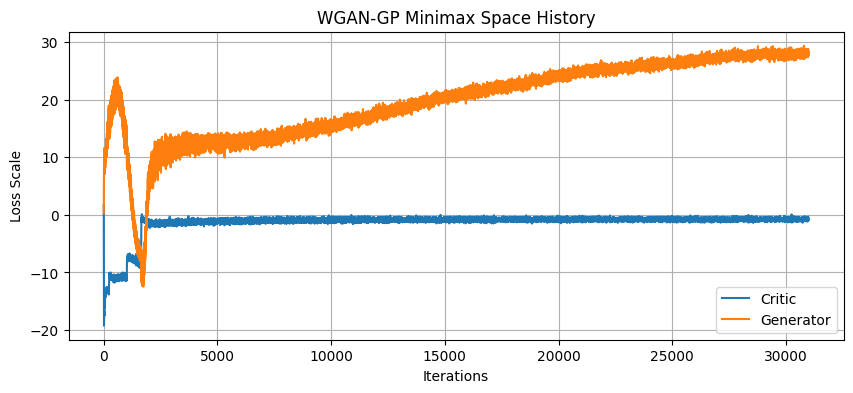

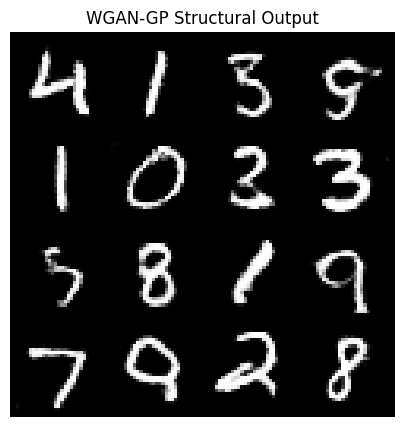

/tmp/ipykernel_58/1689098877.py:54: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma_real.dot(sigma_fake), disp=False)


>> Evaluated FID score for WGAN-GP: 12.5746



In [19]:
class WGAN_Generator(nn.Module):
    def __init__(self):
        super(WGAN_Generator, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 3, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x):
        return self.model(x)

class WGAN_Critic(nn.Module):
    def __init__(self):
        super(WGAN_Critic, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(channels, 64, 4, 2, 1, bias=False),
            nn.LayerNorm([64, 14, 14]),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.LayerNorm([128, 7, 7]),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 3, 2, 1, bias=False),
            nn.LayerNorm([256, 4, 4]),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False)
        )
    def forward(self, x):
        return self.model(x).view(-1, 1)

def compute_gradient_penalty(critic, real_samples, fake_samples):
    alpha = torch.rand(real_samples.size(0), 1, 1, 1, device=device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    critic_interpolates = critic(interpolates)
    gradients = torch.autograd.grad(
        outputs=critic_interpolates, inputs=interpolates,
        grad_outputs=torch.ones(critic_interpolates.size(), device=device),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

netG_wgan = WGAN_Generator().to(device)
netC_wgan = WGAN_Critic().to(device)
lambda_gp = 10.0
n_critic = 3
optG_wgan = optim.Adam(netG_wgan.parameters(), lr=0.0001, betas=(0.0, 0.9))
optC_wgan = optim.Adam(netC_wgan.parameters(), lr=0.0001, betas=(0.0, 0.9))
wgan_losses = {"Critic": [], "Generator": []}
real_features_wgan, fake_features_wgan = [], []
print("Running WGAN-GP optimization cycles...")
for epoch in range(epochs):
    epoch_loss_C = 0.0
    epoch_loss_G = 0.0
    generator_updates = 0
    
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        netC_wgan.zero_grad()
        noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        fake_imgs = netG_wgan(noise)
        gp = compute_gradient_penalty(netC_wgan, real_imgs, fake_imgs.detach())
        loss_C = netC_wgan(fake_imgs.detach()).mean() - netC_wgan(real_imgs).mean() + lambda_gp * gp
        loss_C.backward()
        optC_wgan.step()
        epoch_loss_C += loss_C.item()
        if i % n_critic == 0:
            netG_wgan.zero_grad()

            noise_g = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fresh_fake_imgs = netG_wgan(noise_g)
            loss_G = -netC_wgan(fresh_fake_imgs).mean()
            loss_G.backward()
            optG_wgan.step()
            wgan_losses["Critic"].append(loss_C.item())
            wgan_losses["Generator"].append(loss_G.item())
            epoch_loss_G += loss_G.item()
            generator_updates += 1
            
        if epoch == epochs - 1 and i < 25:
            real_features_wgan.append(get_inception_features(real_imgs))
            fake_features_wgan.append(get_inception_features(fake_imgs))

    avg_loss_C = epoch_loss_C / len(dataloader)
    avg_loss_G = epoch_loss_G / generator_updates if generator_updates > 0 else 0
    print(f"Epoch [{epoch+1}/{epochs}] | Avg Loss Critic: {avg_loss_C:.4f} | Avg Loss Generator: {avg_loss_G:.4f}")

plot_training_loss(wgan_losses, "WGAN-GP Minimax Space History")
show_generated_samples(netG_wgan, latent_dim, "WGAN-GP Structural Output")
real_feats_wgan = np.concatenate(real_features_wgan, axis=0)
fake_feats_wgan = np.concatenate(fake_features_wgan, axis=0)
print(f">> Evaluated FID score for WGAN-GP: {calculate_fid(real_feats_wgan, fake_feats_wgan):.4f}\n")

<a id='st1'></a>
<h1 style = "color:white;" dir = "ltr"> <b>
        BEGAN
        
</b> </h1>

Running BEGAN optimization cycles...
Epoch [1/99] | Avg Loss D: 0.1008 | Avg Loss G: 0.11629777 | Avg M_global: 0.2609 | k_t: 0.0001
Epoch [2/99] | Avg Loss D: 0.0526 | Avg Loss G: 0.01947614 | Avg M_global: 0.0719 | k_t: 0.0164
Epoch [3/99] | Avg Loss D: 0.0468 | Avg Loss G: 0.01291121 | Avg M_global: 0.0673 | k_t: 0.0353
Epoch [4/99] | Avg Loss D: 0.0432 | Avg Loss G: 0.01302277 | Avg M_global: 0.0615 | k_t: 0.0518
Epoch [5/99] | Avg Loss D: 0.0408 | Avg Loss G: 0.01387357 | Avg M_global: 0.0569 | k_t: 0.0661
Epoch [6/99] | Avg Loss D: 0.0390 | Avg Loss G: 0.01499857 | Avg M_global: 0.0532 | k_t: 0.0784
Epoch [7/99] | Avg Loss D: 0.0376 | Avg Loss G: 0.01675098 | Avg M_global: 0.0495 | k_t: 0.0882
Epoch [8/99] | Avg Loss D: 0.0364 | Avg Loss G: 0.01855476 | Avg M_global: 0.0462 | k_t: 0.0958
Epoch [9/99] | Avg Loss D: 0.0354 | Avg Loss G: 0.02006351 | Avg M_global: 0.0438 | k_t: 0.1015
Epoch [10/99] | Avg Loss D: 0.0345 | Avg Loss G: 0.02094866 | Avg M_global: 0.0418 | k_t: 0.1059
Ep

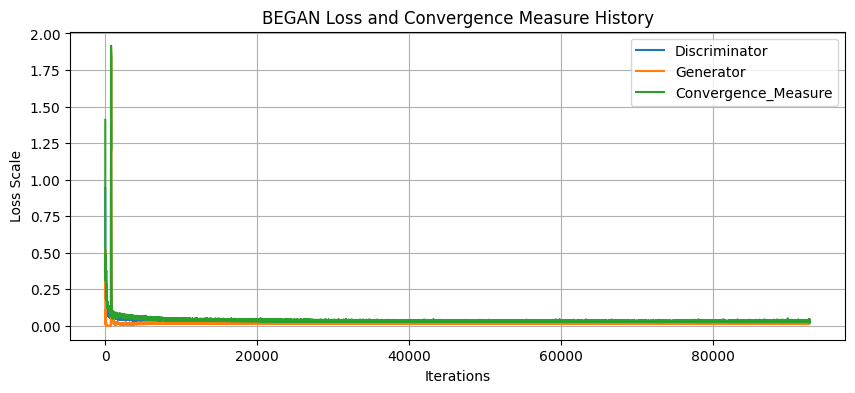


Generating samples for FID evaluation...


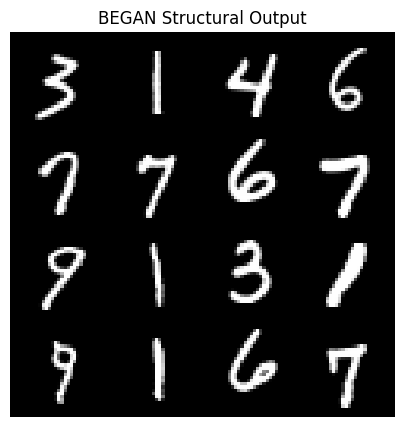

/tmp/ipykernel_58/1689098877.py:54: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma_real.dot(sigma_fake), disp=False)


>> Evaluated FID score for BEGAN: 36.5854



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import torchvision.utils as vutils
import matplotlib.pyplot as plt

def show_generated_samples(generator, latent_dimension, title, num_samples=16, is_began=False):
    generator.eval()
    with torch.no_grad():
        if is_began:
            noise = torch.randn(num_samples, latent_dimension, device=device)
        else:
            noise = torch.randn(num_samples, latent_dimension, 1, 1, device=device)
        fake_images = generator(noise).detach().cpu()
    grid = vutils.make_grid(fake_images, nrow=4, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(5, 5))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.title(title)
    plt.axis("off")
    plt.show()

n_filters = 64  
latent_dim = 32

class BEGAN_Decoder(nn.Module):
    def __init__(self, z_dim):
        super(BEGAN_Decoder, self).__init__()
        self.fc = nn.Linear(z_dim, 7 * 7 * (3 * n_filters))
        
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(3 * n_filters, 3 * n_filters, 3, 1, 1),
            nn.ELU(alpha=1.0, inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(3 * n_filters, 3 * n_filters, 3, 1, 1),
            nn.ELU(alpha=1.0, inplace=True),
            nn.Dropout2d(0.1),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(3 * n_filters, 2 * n_filters, 3, 1, 1),
            nn.ELU(alpha=1.0, inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(2 * n_filters, 2 * n_filters, 3, 1, 1),
            nn.ELU(alpha=1.0, inplace=True),
            nn.Dropout2d(0.1),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(2 * n_filters, n_filters, 3, 1, 1),
            nn.ELU(alpha=1.0, inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(n_filters, n_filters, 3, 1, 1),
            nn.ELU(alpha=1.0, inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(n_filters, channels, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = self.fc(x)
        h = h.view(-1, 3 * n_filters, 7, 7)
        return self.conv_blocks(h)

class BEGAN_Generator(nn.Module):
    def __init__(self):
        super(BEGAN_Generator, self).__init__()
        self.decoder = BEGAN_Decoder(latent_dim)
        
    def forward(self, x):
        return self.decoder(x)

class BEGAN_Discriminator(nn.Module):
    def __init__(self):
        super(BEGAN_Discriminator, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, n_filters, 3, 1, 1),
            nn.ELU(alpha=1.0, inplace=True),
            nn.Conv2d(n_filters, n_filters, 3, 1, 1),
            nn.ELU(alpha=1.0, inplace=True),
            nn.Conv2d(n_filters, 2 * n_filters, 3, 2, 1), 
            nn.ELU(alpha=1.0, inplace=True),
            nn.Conv2d(2 * n_filters, 2 * n_filters, 3, 1, 1),
            nn.ELU(alpha=1.0, inplace=True),
            nn.Conv2d(2 * n_filters, 3 * n_filters, 3, 2, 1), 
            nn.ELU(alpha=1.0, inplace=True),
            nn.Conv2d(3 * n_filters, 3 * n_filters, 3, 1, 1),
            nn.ELU(alpha=1.0, inplace=True)
        )
        self.fc_enc = nn.Linear(7 * 7 * (3 * n_filters), latent_dim)
        self.decoder = BEGAN_Decoder(latent_dim)

    def forward(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        z = self.fc_enc(h)
        out = self.decoder(z)
        return out

netG_began = BEGAN_Generator().to(device)
netD_began = BEGAN_Discriminator().to(device)

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.xavier_uniform_(m.weight)
    elif classname.find('Linear') != -1:
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

netG_began.apply(weights_init)
netD_began.apply(weights_init)

lr_began = 1e-4  
optG_began = optim.Adam(netG_began.parameters(), lr=lr_began, betas=(0.5, 0.999))
optD_began = optim.Adam(netD_began.parameters(), lr=lr_began, betas=(0.5, 0.999))

gamma = 0.7        
lambda_k = 0.001   
k_t = 0.0          
epochs_began = 99
began_losses = {"Discriminator": [], "Generator": [], "Convergence_Measure": []}

print("Running BEGAN optimization cycles...")
for epoch in range(epochs_began):
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0
    epoch_measure = 0.0
    
    netG_began.train()
    netD_began.train()
    
    for i, (real_imgs, _) in enumerate(dataloader):
        bs = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        for p in netD_began.parameters():
            p.requires_grad = True
            
        optD_began.zero_grad(set_to_none=True)
        
        recon_real = netD_began(real_imgs)
        loss_D_real = F.l1_loss(recon_real, real_imgs)
        noise_D = torch.randn(bs, latent_dim, device=device)
        fake_imgs_D = netG_began(noise_D)
        
        recon_fake_D = netD_began(fake_imgs_D.detach())
        loss_D_fake = F.l1_loss(recon_fake_D, fake_imgs_D.detach())
        
        loss_D = loss_D_real - k_t * loss_D_fake
        loss_D.backward()
        optD_began.step()
        
        for p in netD_began.parameters():
            p.requires_grad = False
            
        optG_began.zero_grad(set_to_none=True)
        noise_G = torch.randn(bs, latent_dim, device=device)
        fake_imgs_G = netG_began(noise_G)
        recon_fake_G = netD_began(fake_imgs_G)
        loss_G = F.l1_loss(recon_fake_G, fake_imgs_G)
        loss_G.backward()
        optG_began.step()
        
        balance = (gamma * loss_D_real - loss_G).item()
        k_t = k_t + lambda_k * balance
        k_t = max(min(k_t, 1.0), 0.0) 
        measure = loss_D_real.item() + abs(balance)
        
        began_losses["Discriminator"].append(loss_D.item())
        began_losses["Generator"].append(loss_G.item())
        began_losses["Convergence_Measure"].append(measure)
        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()
        epoch_measure += measure

    avg_loss_D = epoch_loss_D / len(dataloader)
    avg_loss_G = epoch_loss_G / len(dataloader)
    avg_measure = epoch_measure / len(dataloader)
    
    print(f"Epoch [{epoch+1}/{epochs_began}] | Avg Loss D: {avg_loss_D:.4f} | Avg Loss G: {avg_loss_G:.8f} | Avg M_global: {avg_measure:.4f} | k_t: {k_t:.4f}")

plot_training_loss(began_losses, "BEGAN Loss and Convergence Measure History")

print("\nGenerating samples for FID evaluation...")
real_features_began = []
fake_features_began = []
num_fid_samples = 5000
samples_collected = 0

netG_began.eval() 
with torch.no_grad():
    for real_imgs, _ in dataloader:
        if samples_collected >= num_fid_samples:
            break
            
        bs = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        real_features_began.append(get_inception_features(real_imgs))
        noise_G = torch.randn(bs, latent_dim, device=device)
        fake_imgs = netG_began(noise_G)
        fake_features_began.append(get_inception_features(fake_imgs))
        samples_collected += bs

show_generated_samples(netG_began, latent_dim, "BEGAN Structural Output", is_began=True)

real_feats_began = np.concatenate(real_features_began, axis=0)
fake_feats_began = np.concatenate(fake_features_began, axis=0)
final_fid = calculate_fid(real_feats_began, fake_feats_began)

print(f">> Evaluated FID score for BEGAN: {final_fid:.4f}\n")